<a href="https://colab.research.google.com/github/Kaweri05/IMDB_Rating/blob/main/IMDB_Rating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [3]:
df= pd.read_csv('/content/IMDB_Dataset.csv')

In [4]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
49995,False
49996,False
49997,False
49998,False


In [8]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [9]:
df.drop_duplicates()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


## Count Vectorization

As an alternative to TF-IDF, I will now apply Count Vectorization. This method simply counts the occurrences of each word in a document, providing a bag-of-words representation.

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the Count Vectorizer
# min_df and max_df are used similarly to TfidfVectorizer
# ngram_range considers both single words and pairs of words.
count_vectorizer = CountVectorizer(min_df=5, max_df=0.9, ngram_range=(1, 2))

# Fit and transform the training data
X_train_count = count_vectorizer.fit_transform(X_train_cleaned)

# Transform the test data using the fitted vectorizer
X_test_count = count_vectorizer.transform(X_test_cleaned)

print(f"Shape of X_train_count: {X_train_count.shape}")
print(f"Shape of X_test_count: {X_test_count.shape}")

Shape of X_train_count: (40000, 142893)
Shape of X_test_count: (10000, 142893)


## Model Training: Logistic Regression with Count Vectorization

Now I will train another Logistic Regression model using the features generated by `CountVectorizer` to see how it compares to the TF-IDF based model.

In [15]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model for CountVectorizer data
logistic_model_count = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
logistic_model_count.fit(X_train_count, y_train_encoded)

print("Logistic Regression model trained with Count Vectorizer data successfully!")

Logistic Regression model trained with Count Vectorizer data successfully!


## Model Evaluation: Logistic Regression with Count Vectorization

Now that the model has been trained using Count Vectorization, I will evaluate its performance on the test set. This will help us understand how well the model generalizes to unseen data.

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred_count = logistic_model_count.predict(X_test_count)

# Calculate accuracy
accuracy_count = accuracy_score(y_test_encoded, y_pred_count)
print(f"Accuracy with Count Vectorization: {accuracy_count:.4f}")

# Display classification report
print("\nClassification Report (Count Vectorization):\n")
print(classification_report(y_test_encoded, y_pred_count, target_names=label_encoder.classes_))

# Display confusion matrix
print("\nConfusion Matrix (Count Vectorization):\n")
print(confusion_matrix(y_test_encoded, y_pred_count))


Accuracy with Count Vectorization: 0.8982

Classification Report (Count Vectorization):

              precision    recall  f1-score   support

    negative       0.90      0.89      0.90      4961
    positive       0.90      0.90      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000


Confusion Matrix (Count Vectorization):

[[4429  532]
 [ 486 4553]]


## Model Training: Support Vector Machine (SVM) with Count Vectorization

Now, I will train a Support Vector Machine (SVM) model using the features generated by `CountVectorizer`.

In [17]:
from sklearn.svm import SVC

# Initialize the SVM model
# Due to the large number of features, 'linear' kernel is often preferred for text data
# Increase max_iter for convergence with large datasets, though it might still be slow
svm_model_count = SVC(kernel='linear', random_state=42, max_iter=2000) # Increased max_iter

# Train the model
print("Training SVM model... This may take some time.")
svm_model_count.fit(X_train_count, y_train_encoded)

print("SVM model trained with Count Vectorizer data successfully!")

Training SVM model... This may take some time.
SVM model trained with Count Vectorizer data successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


## Model Evaluation: Support Vector Machine (SVM) with Count Vectorization

Now that the SVM model has been trained using Count Vectorization, I will evaluate its performance on the test set.

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred_svm_count = svm_model_count.predict(X_test_count)

# Calculate accuracy
accuracy_svm_count = accuracy_score(y_test_encoded, y_pred_svm_count)
print(f"Accuracy with SVM (Count Vectorization): {accuracy_svm_count:.4f}")

# Display classification report
print("\nClassification Report (SVM with Count Vectorization):\n")
print(classification_report(y_test_encoded, y_pred_svm_count, target_names=label_encoder.classes_))

# Display confusion matrix
print("\nConfusion Matrix (SVM with Count Vectorization):\n")
print(confusion_matrix(y_test_encoded, y_pred_svm_count))

Accuracy with SVM (Count Vectorization): 0.7788

Classification Report (SVM with Count Vectorization):

              precision    recall  f1-score   support

    negative       0.78      0.77      0.78      4961
    positive       0.78      0.79      0.78      5039

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000


Confusion Matrix (SVM with Count Vectorization):

[[3817 1144]
 [1068 3971]]


## Feature Scaling for SVM

To address the `ConvergenceWarning` and potentially improve the performance of the SVM model, I will now apply `StandardScaler` to the Count Vectorization features. Scaling the data can help the SVM optimizer converge more effectively.

In [19]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler(with_mean=False) # with_mean=False for sparse matrices

# Scale the training data
X_train_count_scaled = scaler.fit_transform(X_train_count)

# Scale the test data
X_test_count_scaled = scaler.transform(X_test_count)

print("Count Vectorization features scaled successfully!")

Count Vectorization features scaled successfully!


## Re-training SVM with Scaled Count Vectorization Features

Now that the Count Vectorization features have been scaled, I will re-train the Support Vector Machine (SVM) model using this scaled data.

In [20]:
from sklearn.svm import SVC

# Initialize the SVM model again
# Using 'linear' kernel and increased max_iter, now with scaled data
svm_model_count_scaled = SVC(kernel='linear', random_state=42, max_iter=2000)

# Train the model with scaled data
print("Training SVM model with scaled data... This may take some time.")
svm_model_count_scaled.fit(X_train_count_scaled, y_train_encoded)

print("SVM model trained with scaled Count Vectorizer data successfully!")

Training SVM model with scaled data... This may take some time.
SVM model trained with scaled Count Vectorizer data successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


## Re-evaluation of SVM with Scaled Count Vectorization Features

Finally, I will evaluate the performance of the re-trained SVM model on the scaled test set to see if scaling improved its accuracy and convergence.

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the scaled test set
y_pred_svm_count_scaled = svm_model_count_scaled.predict(X_test_count_scaled)

# Calculate accuracy
accuracy_svm_count_scaled = accuracy_score(y_test_encoded, y_pred_svm_count_scaled)
print(f"Accuracy with SVM (Scaled Count Vectorization): {accuracy_svm_count_scaled:.4f}")

# Display classification report
print("\nClassification Report (SVM with Scaled Count Vectorization):\n")
print(classification_report(y_test_encoded, y_pred_svm_count_scaled, target_names=label_encoder.classes_))

# Display confusion matrix
print("\nConfusion Matrix (SVM with Scaled Count Vectorization):\n")
print(confusion_matrix(y_test_encoded, y_pred_svm_count_scaled))

Accuracy with SVM (Scaled Count Vectorization): 0.7175

Classification Report (SVM with Scaled Count Vectorization):

              precision    recall  f1-score   support

    negative       0.72      0.69      0.71      4961
    positive       0.71      0.74      0.73      5039

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000


Confusion Matrix (SVM with Scaled Count Vectorization):

[[3442 1519]
 [1306 3733]]


## Model Training: LinearSVC with Original Count Vectorization Features

Given the issues with `SVC` and sparse data, I will now try `LinearSVC`, which is specifically optimized for linear classification on large datasets, especially with sparse inputs.

In [22]:
from sklearn.svm import LinearSVC

# Initialize LinearSVC model
# LinearSVC is often faster and more suitable for large-scale text classification
# with sparse matrices compared to SVC(kernel='linear').
# Dual=False is recommended when n_samples > n_features for better performance.
linear_svc_model_count = LinearSVC(random_state=42, max_iter=2000, dual=False)

# Train the model
print("Training LinearSVC model with original Count Vectorizer data... This may take some time.")
linear_svc_model_count.fit(X_train_count, y_train_encoded)

print("LinearSVC model trained with original Count Vectorizer data successfully!")

Training LinearSVC model with original Count Vectorizer data... This may take some time.
LinearSVC model trained with original Count Vectorizer data successfully!


## Model Evaluation: LinearSVC with Original Count Vectorization Features

Let's evaluate the performance of the `LinearSVC` model trained with the original Count Vectorization features.

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred_linear_svc_count = linear_svc_model_count.predict(X_test_count)

# Calculate accuracy
accuracy_linear_svc_count = accuracy_score(y_test_encoded, y_pred_linear_svc_count)
print(f"Accuracy with LinearSVC (Original Count Vectorization): {accuracy_linear_svc_count:.4f}")

# Display classification report
print("\nClassification Report (LinearSVC with Original Count Vectorization):\n")
print(classification_report(y_test_encoded, y_pred_linear_svc_count, target_names=label_encoder.classes_))

# Display confusion matrix
print("\nConfusion Matrix (LinearSVC with Original Count Vectorization):\n")
print(confusion_matrix(y_test_encoded, y_pred_linear_svc_count))

Accuracy with LinearSVC (Original Count Vectorization): 0.8895

Classification Report (LinearSVC with Original Count Vectorization):

              precision    recall  f1-score   support

    negative       0.89      0.88      0.89      4961
    positive       0.89      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Confusion Matrix (LinearSVC with Original Count Vectorization):

[[4374  587]
 [ 518 4521]]


## Model Training: LinearSVC with Scaled Count Vectorization Features

Now I will train a `LinearSVC` model using the *scaled* Count Vectorization features to see if scaling provides any further benefit for this optimized SVM variant.

In [24]:
from sklearn.svm import LinearSVC

# Initialize LinearSVC model
linear_svc_model_count_scaled = LinearSVC(random_state=42, max_iter=2000, dual=False)

# Train the model with scaled data
print("Training LinearSVC model with scaled Count Vectorizer data... This may take some time.")
linear_svc_model_count_scaled.fit(X_train_count_scaled, y_train_encoded)

print("LinearSVC model trained with scaled Count Vectorizer data successfully!")

Training LinearSVC model with scaled Count Vectorizer data... This may take some time.
LinearSVC model trained with scaled Count Vectorizer data successfully!


## Model Evaluation: LinearSVC with Scaled Count Vectorization Features

Let's evaluate the performance of the `LinearSVC` model trained with the scaled Count Vectorization features.

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the scaled test set
y_pred_linear_svc_count_scaled = linear_svc_model_count_scaled.predict(X_test_count_scaled)

# Calculate accuracy
accuracy_linear_svc_count_scaled = accuracy_score(y_test_encoded, y_pred_linear_svc_count_scaled)
print(f"Accuracy with LinearSVC (Scaled Count Vectorization): {accuracy_linear_svc_count_scaled:.4f}")

# Display classification report
print("\nClassification Report (LinearSVC with Scaled Count Vectorization):\n")
print(classification_report(y_test_encoded, y_pred_linear_svc_count_scaled, target_names=label_encoder.classes_))

# Display confusion matrix
print("\nConfusion Matrix (LinearSVC with Scaled Count Vectorization):\n")
print(confusion_matrix(y_test_encoded, y_pred_linear_svc_count_scaled))

Accuracy with LinearSVC (Scaled Count Vectorization): 0.8612

Classification Report (LinearSVC with Scaled Count Vectorization):

              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      4961
    positive       0.86      0.87      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


Confusion Matrix (LinearSVC with Scaled Count Vectorization):

[[4227  734]
 [ 654 4385]]


## Model Training: LinearSVC with TF-IDF Vectorization Features

To further compare model performance, I will now train a `LinearSVC` model using the `TF-IDF` vectorized features.

In [28]:
from sklearn.svm import LinearSVC

# Initialize LinearSVC model with TF-IDF features
linear_svc_model_tfidf = LinearSVC(random_state=42, max_iter=2000, dual=False)

# Train the model
print("Training LinearSVC model with TF-IDF Vectorizer data... This may take some time.")
linear_svc_model_tfidf.fit(X_train_tfidf, y_train_encoded)

print("LinearSVC model trained with TF-IDF Vectorizer data successfully!")

Training LinearSVC model with TF-IDF Vectorizer data... This may take some time.
LinearSVC model trained with TF-IDF Vectorizer data successfully!


## Model Evaluation: LinearSVC with TF-IDF Vectorization Features

Let's evaluate the performance of the `LinearSVC` model trained with `TF-IDF` features on the test set.

## Saving the Model and Components for Deployment

To deploy our sentiment analysis model, we need to save the trained `LinearSVC` model, the `TfidfVectorizer` (to transform new text input), and the `LabelEncoder` (to convert numerical predictions back to sentiment labels). We'll use the `joblib` library for this, as it's efficient for saving and loading scikit-learn objects.

In [31]:
import joblib

# Define filenames for the saved components
model_filename = 'linear_svc_tfidf_model.pkl'
vectorizer_filename = 'tfidf_vectorizer.pkl'
label_encoder_filename = 'label_encoder.pkl'

# Save the LinearSVC model
joblib.dump(linear_svc_model_tfidf, model_filename)
print(f"Model saved as {model_filename}")

# Save the TF-IDF Vectorizer
joblib.dump(tfidf_vectorizer, vectorizer_filename)
print(f"TF-IDF Vectorizer saved as {vectorizer_filename}")

# Save the LabelEncoder
joblib.dump(label_encoder, label_encoder_filename)
print(f"Label Encoder saved as {label_encoder_filename}")

Model saved as linear_svc_tfidf_model.pkl
TF-IDF Vectorizer saved as tfidf_vectorizer.pkl
Label Encoder saved as label_encoder.pkl


## Creating a Streamlit Application File

Here's a basic `streamlit_app.py` file that demonstrates how to load these components and use them to perform sentiment analysis on new user input. You can run this file locally with Streamlit after downloading the `.pkl` files.

To run the Streamlit app:
1. Save the code below into a file named `streamlit_app.py`.
2. Ensure the `.pkl` files (`linear_svc_tfidf_model.pkl`, `tfidf_vectorizer.pkl`, `label_encoder.pkl`) are in the same directory as `streamlit_app.py`.
3. Open your terminal, navigate to that directory, and run: `streamlit run streamlit_app.py`

In [32]:
%%writefile streamlit_app.py
import streamlit as st
import joblib
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Ensure NLTK data is available (for deployment, you might pre-download these)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Load the pre-trained model and vectorizer
try:
    model = joblib.load('linear_svc_tfidf_model.pkl')
    vectorizer = joblib.load('tfidf_vectorizer.pkl')
    label_encoder = joblib.load('label_encoder.pkl')
    st.success("Model and components loaded successfully!")
except FileNotFoundError:
    st.error("Error: Model or vectorizer files not found. Please ensure 'linear_svc_tfidf_model.pkl', 'tfidf_vectorizer.pkl', and 'label_encoder.pkl' are in the same directory.")
    st.stop()

# Initialize lemmatizer and stopwords for preprocessing
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # 2. Remove special characters and numbers, keep only letters
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # 3. Convert to lowercase
    text = text.lower()
    # 4. Tokenization
    tokens = text.split()
    # 5. Remove stopwords and 6. Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

st.title("IMDB Movie Review Sentiment Analysis")
st.write("Enter a movie review below to get its sentiment (positive/negative).")

user_input = st.text_area("Enter your movie review here:", "This movie was absolutely fantastic! I loved every minute of it.")

if st.button("Analyze Sentiment"):
    if user_input:
        # Preprocess the input text
        cleaned_input = preprocess_text(user_input)

        # Vectorize the cleaned text
        input_vectorized = vectorizer.transform([cleaned_input])

        # Make prediction
        prediction_encoded = model.predict(input_vectorized)

        # Decode the prediction
        prediction_sentiment = label_encoder.inverse_transform(prediction_encoded)[0]

        st.subheader("Analysis Result:")
        if prediction_sentiment == 'positive':
            st.success(f"Sentiment: **{prediction_sentiment.upper()}** 😊")
        else:
            st.error(f"Sentiment: **{prediction_sentiment.upper()}** 😠")
    else:
        st.warning("Please enter some text to analyze.")


Writing streamlit_app.py


## Downloadable Files

Here are the commands to download the saved model, vectorizer, label encoder, and the Streamlit application file. You can run these cells to get all the necessary files for deployment.

## Generate `requirements.txt`

This file lists all the Python dependencies required to run your Streamlit application. It's crucial for ensuring that the deployment environment has all the necessary libraries installed.

In [34]:
%%writefile requirements.txt
streamlit
scikit-learn
nltk
joblib

Writing requirements.txt


## Download `requirements.txt`

Run the cell below to download the `requirements.txt` file.

In [35]:
from google.colab import files

files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
from google.colab import files

# Download the model file
files.download(model_filename)

# Download the vectorizer file
files.download(vectorizer_filename)

# Download the label encoder file
files.download(label_encoder_filename)

# Download the Streamlit app file
files.download('streamlit_app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set (TF-IDF)
y_pred_linear_svc_tfidf = linear_svc_model_tfidf.predict(X_test_tfidf)

# Calculate accuracy
accuracy_linear_svc_tfidf = accuracy_score(y_test_encoded, y_pred_linear_svc_tfidf)
print(f"Accuracy with LinearSVC (TF-IDF Vectorization): {accuracy_linear_svc_tfidf:.4f}")

# Display classification report
print("\nClassification Report (LinearSVC with TF-IDF Vectorization):\n")
print(classification_report(y_test_encoded, y_pred_linear_svc_tfidf, target_names=label_encoder.classes_))

# Display confusion matrix
print("\nConfusion Matrix (LinearSVC with TF-IDF Vectorization):\n")
print(confusion_matrix(y_test_encoded, y_pred_linear_svc_tfidf))

Accuracy with LinearSVC (TF-IDF Vectorization): 0.9094

Classification Report (LinearSVC with TF-IDF Vectorization):

              precision    recall  f1-score   support

    negative       0.91      0.90      0.91      4961
    positive       0.90      0.92      0.91      5039

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000


Confusion Matrix (LinearSVC with TF-IDF Vectorization):

[[4472  489]
 [ 417 4622]]


## Visualizing Model Performance

To provide a clear overview, I will now plot a bar chart comparing the accuracy of each model we've trained and evaluated.

/tmp/ipykernel_2426/1205478084.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')


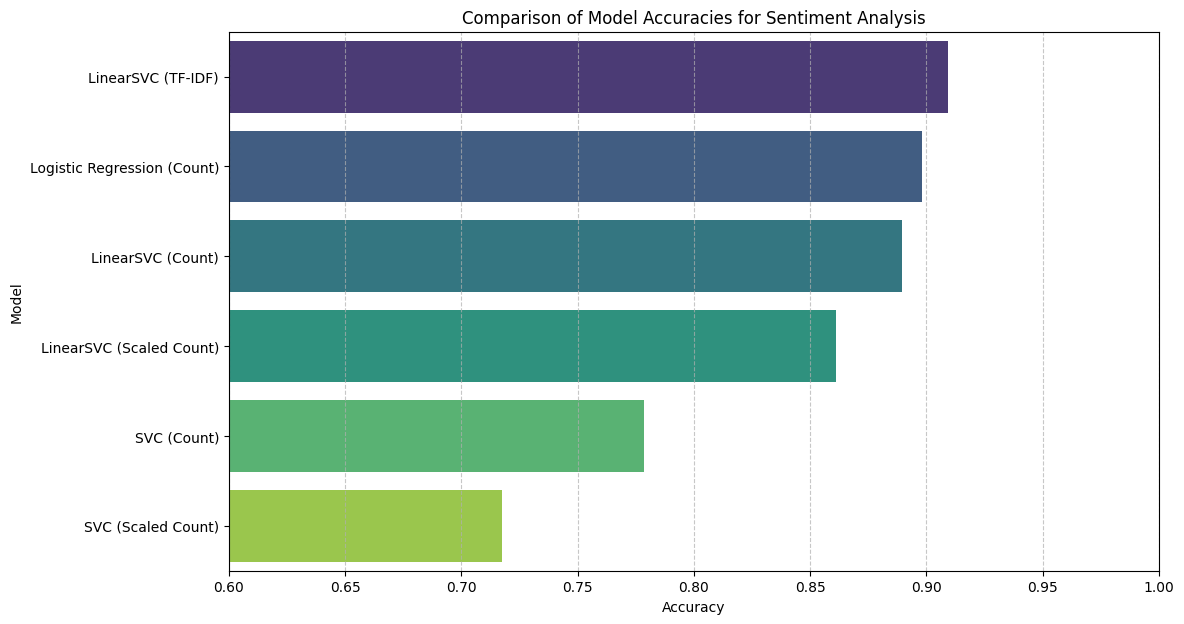

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Collect accuracies from the global variables
model_accuracies = {
    'Logistic Regression (Count)': accuracy_count,
    'SVC (Count)': accuracy_svm_count,
    'SVC (Scaled Count)': accuracy_svm_count_scaled,
    'LinearSVC (Count)': accuracy_linear_svc_count,
    'LinearSVC (Scaled Count)': accuracy_linear_svc_count_scaled,
    'LinearSVC (TF-IDF)': accuracy_linear_svc_tfidf
}

# Convert to a DataFrame for easy plotting
accuracy_df = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')
plt.title('Comparison of Model Accuracies for Sentiment Analysis')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0.6, 1.0) # Set x-axis limit to better show differences
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Model Training: LinearSVC with TF-IDF Vectorization Features

To further compare model performance, I will now train a `LinearSVC` model using the `TF-IDF` vectorized features.

In [26]:
from sklearn.svm import LinearSVC

# Initialize LinearSVC model with TF-IDF features
linear_svc_model_tfidf = LinearSVC(random_state=42, max_iter=2000, dual=False)

# Train the model
print("Training LinearSVC model with TF-IDF Vectorizer data... This may take some time.")
linear_svc_model_tfidf.fit(X_train_tfidf, y_train_encoded)

print("LinearSVC model trained with TF-IDF Vectorizer data successfully!")

Training LinearSVC model with TF-IDF Vectorizer data... This may take some time.
LinearSVC model trained with TF-IDF Vectorizer data successfully!


## Model Evaluation: LinearSVC with TF-IDF Vectorization Features

Let's evaluate the performance of the `LinearSVC` model trained with `TF-IDF` features on the test set.

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set (TF-IDF)
y_pred_linear_svc_tfidf = linear_svc_model_tfidf.predict(X_test_tfidf)

# Calculate accuracy
accuracy_linear_svc_tfidf = accuracy_score(y_test_encoded, y_pred_linear_svc_tfidf)
print(f"Accuracy with LinearSVC (TF-IDF Vectorization): {accuracy_linear_svc_tfidf:.4f}")

# Display classification report
print("\nClassification Report (LinearSVC with TF-IDF Vectorization):\n")
print(classification_report(y_test_encoded, y_pred_linear_svc_tfidf, target_names=label_encoder.classes_))

# Display confusion matrix
print("\nConfusion Matrix (LinearSVC with TF-IDF Vectorization):\n")
print(confusion_matrix(y_test_encoded, y_pred_linear_svc_tfidf))

Accuracy with LinearSVC (TF-IDF Vectorization): 0.9094

Classification Report (LinearSVC with TF-IDF Vectorization):

              precision    recall  f1-score   support

    negative       0.91      0.90      0.91      4961
    positive       0.90      0.92      0.91      5039

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000


Confusion Matrix (LinearSVC with TF-IDF Vectorization):

[[4472  489]
 [ 417 4622]]


## Split and Train the Data

Now, I will split the data into training and testing sets to prepare it for model training. The `review` column will be our features (X), and the `sentiment` column will be our target (y).

In [10]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df['review']
y = df['sentiment']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (40000,)
X_test shape: (10000,)
y_train shape: (40000,)
y_test shape: (10000,)


## Label Encoding for Sentiment

The `sentiment` column contains categorical string values ('positive' and 'negative'). To prepare this data for machine learning models, I will convert these labels into numerical format using `LabelEncoder`.

In [11]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Fit the encoder on the training labels and transform both training and test labels
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Display the mapping
print("Original labels:", label_encoder.classes_)
print("Encoded labels:", label_encoder.transform(label_encoder.classes_))

# Display a sample of the encoded labels
print("\nSample of encoded y_train:")
print(y_train_encoded[:5])
print("\nSample of encoded y_test:")
print(y_test_encoded[:5])

Original labels: ['negative' 'positive']
Encoded labels: [0 1]

Sample of encoded y_train:
[0 0 1 0 0]

Sample of encoded y_test:
[1 1 0 1 0]


## Text Preprocessing

Before training a model on the text data, it's essential to preprocess it. This involves several steps to clean and standardize the text, which helps improve the model's performance. I'll define a function to perform these steps:

1.  **Remove HTML tags**: Many reviews contain `<br />` tags that are not useful for analysis.
2.  **Remove special characters and numbers**: Keep only alphabetic characters.
3.  **Convert to lowercase**: Ensure consistency.
4.  **Tokenization**: Break down sentences into individual words.
5.  **Remove stopwords**: Eliminate common words (like 'the', 'is', 'a') that don't carry much meaning.
6.  **Lemmatization**: Reduce words to their base form (e.g., 'running' to 'run') to reduce vocabulary size and improve generalization.

In [12]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # 2. Remove special characters and numbers, keep only letters
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # 3. Convert to lowercase
    text = text.lower()
    # 4. Tokenization
    tokens = text.split()
    # 5. Remove stopwords and 6. Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply preprocessing to training and testing data
X_train_cleaned = X_train.apply(preprocess_text)
X_test_cleaned = X_test.apply(preprocess_text)

print("Original X_train sample:")
print(X_train.iloc[0])
print("\nCleaned X_train sample:")
print(X_train_cleaned.iloc[0])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Original X_train sample:
That's what I kept asking myself during the many fights, screaming matches, swearing and general mayhem that permeate the 84 minutes. The comparisons also stand up when you think of the one-dimensional characters, who have so little depth that it is virtually impossible to care what happens to them. They are just badly written cyphers for the director to hang his multicultural beliefs on, a topic that has been done much better in other dramas both on TV and the cinema.<br /><br />I must confess, I'm not really one for spotting bad performances during a film, but it must be said that Nichola Burley (as the heroine's slutty best friend) and Wasim Zakir (as the nasty, bullying brother) were absolutely terrible. I don't know what acting school they graduated from, but if I was them I'd apply for a full refund post haste. Only Samina Awan in the lead role manages to impress in a cast of so-called British talent that we'll probably never hear from again. At least, th

## TF-IDF Vectorization

After cleaning the text data, the next step is to convert it into a numerical representation that machine learning models can understand. I will use the TF-IDF (Term Frequency-Inverse Document Frequency) vectorization technique. TF-IDF reflects the importance of a word in a document relative to its importance in the entire corpus.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF Vectorizer
# min_df ignores terms that have a document frequency strictly lower than the given threshold.
# max_df ignores terms that have a document frequency strictly higher than the given threshold.
# ngram_range considers both single words and pairs of words.
tfidf_vectorizer = TfidfVectorizer(min_df=5, max_df=0.9, ngram_range=(1, 2))

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_cleaned)

# Transform the test data using the fitted vectorizer
X_test_tfidf = tfidf_vectorizer.transform(X_test_cleaned)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")


Shape of X_train_tfidf: (40000, 142893)
Shape of X_test_tfidf: (10000, 142893)


## Model Training: Logistic Regression

With the text data preprocessed and vectorized using TF-IDF, I will now train a Logistic Regression model. Logistic Regression is a good baseline model for text classification tasks due to its simplicity and interpretability.